# **Exploração e análise de dados de crédito SQL no AWS Athena**

*Esse notebook pertence a um projeto de linguagem SQL da EBAC.*

## Os dados: 

As seguintes colunas estão presentes: 

* idade = idade do cliente
* sexo = sexo do cliente (F ou M)
* dependentes = número de dependentes do cliente
* escolaridade = nível de escolaridade do clientes
* salario_anual = faixa salarial do cliente
* tipo_cartao = tipo de cartao do cliente
* qtd_produtos = quantidade de produtos comprados nos últimos 12 meses
* iteracoes_12m = quantidade de iterações/transacoes nos ultimos 12 meses
* meses_inativo_12m = quantidade de meses que o cliente ficou inativo
* limite_credito = limite de credito do cliente
* valor_transacoes_12m = valor das transações dos ultimos 12 meses
* qtd_transacoes_12m  = quantidade de transacoes dos ultimos 12 meses

A tabela foi criada no **AWS Athena** junto com o **S3 Bucket**, os dados estão disponibilizados no ![Github](https://github.com/andre-marcos-perez/ebac-course-utils/tree/main/dataset)

Os dados sofreram uma diminuição em seu tamanho para impactar menos nas consultas do Athena.

## **Exploração de dados:**

E bom começar visualizando os dados para entender-mos com o que estamos lidando.

**Qual a quantidade de informações disponível?**

Query: SELECT count(*) FROM credito
> Reposta: 2564 linhas


**Como são os dados** 

Query: SELECT * FROM credito LIMIT 10;
![Dez primeiras linhas do dataset](https://github.com/marianeneiva/sqlEBAC/blob/main/limit10.png?raw=true)

> Algumas informações nulas estão presentes na tabela (valores na). 

**Quais os tipos de cada dado**

**Query:** DESCRIBE credito

![Descrição dos tipos de dados](https://github.com/marianeneiva/sqlEBAC/blob/main/describe.png?raw=true)


Já vimos com quais tipos de dados estamos trabalhando, mas agora olharemos para as variaveis categóricas.
**Que informações a coluna escolaridade possui?**

**Query:** SELECT DISTINCT escolaridade FROM credito

![Tipos de escolaridade](https://github.com/marianeneiva/sqlEBAC/blob/main/escolaridade.png?raw=true)

> os dados tem alguns niveis de escolaridade,por mais que ainda tenha dados nulos(na), serão tratados mais tarde!

Será que temos mais valores nulos?

**Quais tipos de estado_civil estão presentes?**

**Query:** SELECT DISTINCT estado_civil  FROM credito

![Tipos de estado civil](https://github.com/marianeneiva/sqlEBAC/blob/main/escolaridade.png?raw=true)

> Por hora os dados nulos continuam presentes!

**Quais são os parametros de salario_anual presentes?**

**Query:** SELECT DISTINCT salario_anual  FROM credito

![Tipos de salario anual](https://github.com/marianeneiva/sqlEBAC/blob/main/salario_anual.png?raw=true)

> Os salários não tem valores exatos, apenas é mostrado a faixa anual de cada usuário, e Também contem dados nulos. 


**Tipos de cartão disponíveis?**

**Query:** SELECT DISTINCT tipo_cartao  FROM credito

![Tipos de cartão](https://github.com/marianeneiva/sqlEBAC/blob/main/cartao.png?raw=true)

> Aqui vemos a ausência de dados nulos.







## **Análise de dados**

Com os dados devidamente apresentados, é hora de analisa-los para ver que tipos de insights podem ser tirados.
**Nesse banco de dados, quantos clientes temos de cada faixa salarial?**

**Query:** select count(*), salario_anual from credito group by salario_anual

![Quantidade para cada faixa salarial](https://github.com/marianeneiva/sqlEBAC/blob/main/faixa_salarial.png?raw=true)

 

Vamos ver a distribuição da Faixa salarial de outra forma.

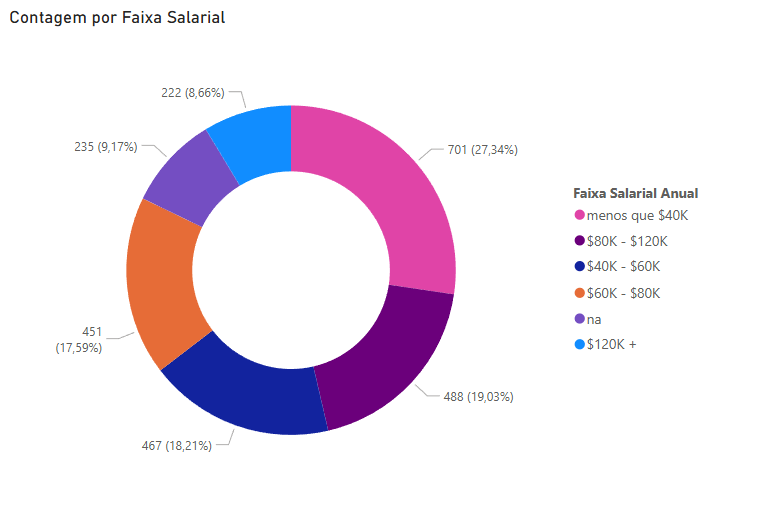

> Quase 30 % das pessoas nesssa base de dados possui um renda menor que 40K e quase 10 % dos clientes não informaram ou a faixa salarial não é constada. 
> Ao que foi mostrado, seria  proveitoso de certa forma, que a empresa focasse atenção nesse público de mais baixa renda.

**Qual a proporção de homens e mulheres?**

**Query:** select count(*), sexo from credito group by sexo


![Quantidade para cada sexo](https://github.com/marianeneiva/sqlEBAC/blob/main/faixa_sexo.png?raw=true)

![Quantidade para cada sexo - gráfico](https://github.com/marianeneiva/sqlEBAC/blob/main/qtde_por_sexo.png?raw=true)

> A maior parte dos clientes são homens!

**Qual a faixa etária dos clientes?**

**Query:** select avg(idade) as media_idade, min(idade) as min_idade, max(idade) as max_idade, sexo from credito group by sexo
![Média de idades por sexo](https://github.com/marianeneiva/sqlEBAC/blob/main/idade_sexopng.png?raw=true)

> As idades dos homens e das mulheres não possuem  grandes diferenças, então não foi tirado nenhuma informação relevante.


**Qual a maior e menor transação dos clientes?**

**Query:** select min(valor_transacoes_12m) as transacao_minima, max(valor_transacoes_12m) as transacao_minima from credito
![Valor transacoes](https://github.com/marianeneiva/sqlEBAC/blob/main/transacoes.png?raw=true)

> As transações em 12 meses variam de 510.16 a 5776.58.

**Quais as características dos clientes que possuem os maiores creditos?**

**Query:** 
select max(limite_credito) as limite_credito, escolaridade, tipo_cartao, sexo 
from credito
where escolaridade != 'na' and tipo_cartao != 'na' 
group by  escolaridade, tipo_cartao, sexo 
order by limite_credito desc
limit 10

![Valor limite](https://github.com/marianeneiva/sqlEBAC/blob/main/limite_desc.png?raw=true)

> A escolaridade não representa impacto considerável no limite de credito. O limite mais alto é oferecido para um homem sem educação formal.
> O cartão também parece não estar relacionado com a escolaridade nem com o limite. Dentre os maiores limites, encontramos clientes com cartão: gold, silver, platinum e blue

**Quais as características dos clientes que possuem os menores creditos?**

**Query:** 
select max(limite_credito) as limite_credito, escolaridade, tipo_cartao, sexo 
from credito
where escolaridade != 'na' and tipo_cartao != 'na' 
group by  escolaridade, tipo_cartao, sexo 
order by limite_credito asc


![Valor limite](https://github.com/marianeneiva/sqlEBAC/blob/main/limite_asc.png?raw=true)

> Agora pe perceptivel a falta de clientes com cartão platinum  em limites menores.
> E as mulheres  possuem grande parte dos limites menores, ao contrário dos homens, na qual os limites são bem maiores.

**Quais tem maiores gastos? Homens ou Mulheres?**

**Query:** 
select max(valor_transacoes_12m) as maior_valor_gasto, avg(valor_transacoes_12m) as  media_valor_gasto, min(valor_transacoes_12m) as min_valor_gasto, sexo 
from credito
group by sexo 


![Valor transacoes/sexo](https://github.com/marianeneiva/sqlEBAC/blob/main/quemgastamais.png?raw=true)

> Por mais que os gastos apresentem diferenças, ainda se mantem equiparáveis. 

Por fim, 


**O limite de credito é impactado pelo Salario?**

**Query:** select avg(qtd_produtos) as qts_produtos, avg(valor_transacoes_12m) as media_valor_transacoes, avg(limite_credito) as media_limite,  sexo,   salario_anual from credito 
where salario_anual != 'na'
group by sexo, salario_anual
order by avg(valor_transacoes_12m) desc

![Valor salario_anualLimite](https://github.com/marianeneiva/sqlEBAC/blob/main/salarioAnualMediaLimite.png?raw=true)

>SIM! As pessoas que tem menor faixa salarial também apresentam menor limite de credito!









# Conclusão

As análises realizadas se mostraram frutíferas e apresentaram algumas insights interessantes:

- 30% dos clientes possui renda até 40K. 
- Mais de 60% dos clientes são do gênero masculino!
- A escolaridade não gera influencia no limite de credito e nem no tipo do cartão(Ao menos não nesses dados).
- Os clientes com maiores limites são em sua maioria homens.
- Os clientes com menores limites são em sua maioria mulheres.
- Dentre os menores limites não há presença de cartão platinum.
- A faixa salarial impacta diretamente no limite de crédito.
- Não existem clientes com salário anual acima de 60K do sexo feminino.

### Nesse caso, realizar uma exploração maior e prolongada poderia explicar o motivo dos clientes do gênero feminino possuirem credito menor, especulações podem ser pensadas, mas com a análise atual é isso que podemos tirar dos dados disponibilizados.

